In [10]:
import pandas as pd
import numpy as np
cardata = cardata = pd.read_csv('CarSalesData.csv')


In [6]:
# cardata.head()
# cardata.shape
# cardata.info()
cardata.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner


In [11]:
#Extract Brand
cardata["Brand"] = cardata["name"].str.split().str[0]
cardata.loc[
    cardata["name"].str.startswith("Land Rover"),
    "Brand"
] = "Land Rover"


cardata[["Brand","name"]]


,Brand,name
0,Maruti,Maruti 800 AC
1,Maruti,Maruti Wagon R LXI Minor
2,Hyundai,Hyundai Verna 1.6 SX
3,Datsun,Datsun RediGO T Option
4,Honda,Honda Amaze VX i-DTEC
...,...,...
4335,Hyundai,Hyundai i20 Magna 1.4 CRDi (Diesel)
4336,Hyundai,Hyundai i20 Magna 1.4 CRDi
4337,Maruti,Maruti 800 AC BSIII
4338,Hyundai,Hyundai Creta 1.6 CRDi SX Option


In [43]:
#Car Age
cardata["car_age"] = 2026 - cardata["year"]
cardata[['Brand','name','car_age']]

,Brand,name,car_age
0,Maruti,Maruti 800 AC,19
1,Maruti,Maruti Wagon R LXI Minor,19
2,Hyundai,Hyundai Verna 1.6 SX,14
3,Datsun,Datsun RediGO T Option,9
4,Honda,Honda Amaze VX i-DTEC,12
...,...,...,...
4335,Hyundai,Hyundai i20 Magna 1.4 CRDi (Diesel),12
4336,Hyundai,Hyundai i20 Magna 1.4 CRDi,12
4337,Maruti,Maruti 800 AC BSIII,17
4338,Hyundai,Hyundai Creta 1.6 CRDi SX Option,10


In [108]:
#Which brands dominate the used car market?(Top 10)
cardata["Brand"].value_counts().head(10)

Brand
Maruti        1280
Hyundai        821
Mahindra       365
Tata           361
Honda          252
Ford           238
Toyota         206
Chevrolet      188
Renault        146
Volkswagen     107
Name: count, dtype: int64

In [ ]:
#Which brands have the highest average resale price?(In Lakhs)
resale_value = cardata.groupby("Brand")["selling_price"].mean().sort_values(ascending=False).head(10).apply(lambda x: f"{x/100000:.2f} Lakhs")

resale_value

Brand
Land Rover       36.10 Lakhs
BMW              29.45 Lakhs
Mercedes-Benz    27.77 Lakhs
Volvo            25.56 Lakhs
Jaguar           20.69 Lakhs
Audi             19.32 Lakhs
MG               18.43 Lakhs
Jeep             15.30 Lakhs
Isuzu            15.00 Lakhs
Kia              13.00 Lakhs
Name: selling_price, dtype: object

In [114]:
cardata["name"].head(10)

0                Maruti 800 AC
1     Maruti Wagon R LXI Minor
2         Hyundai Verna 1.6 SX
3       Datsun RediGO T Option
4        Honda Amaze VX i-DTEC
5         Maruti Alto LX BSIII
6    Hyundai Xcent 1.2 Kappa S
7     Tata Indigo Grand Petrol
8     Hyundai Creta 1.6 VTVT S
9     Maruti Celerio Green VXI
Name: name, dtype: object

In [137]:
# Does mileage impact price?
cardata["km_driven"].corr(cardata["selling_price"])

np.float64(-0.1922886305451144)

In [141]:
#automatic vs manual resale value
transmission_price = (
    cardata.groupby("transmission")["selling_price"].agg(['mean', 'median']).div(100000).round(2).astype(str).add(" Lakhs"))

transmission_price

,mean,median
transmission,,
Automatic,14.08 Lakhs,9.5 Lakhs
Manual,4.0 Lakhs,3.25 Lakhs


In [41]:
#Which fuel type has the highest average resale price?
highest_avg_resale = (cardata.groupby("fuel")["selling_price"].mean().div(100000).round(2).astype(str).add(" Lakhs"))

In [42]:
highest_avg_resale

fuel
CNG         2.77 Lakhs
Diesel      6.69 Lakhs
Electric     3.1 Lakhs
LPG         1.68 Lakhs
Petrol      3.45 Lakhs
Name: selling_price, dtype: object

In [13]:
#Does ownership history affect resale value
ownership = (cardata.groupby("owner")["selling_price"].agg(["mean","median"]).div({'mean': 100000, 'median': 100000}).round(2).astype(str).add(" Lakhs"))

In [173]:
ownership

,mean,median
owner,,
First Owner,5.99 Lakhs,4.5 Lakhs
Fourth & Above Owner,1.74 Lakhs,1.3 Lakhs
Second Owner,3.44 Lakhs,2.5 Lakhs
Test Drive Car,9.54 Lakhs,8.95 Lakhs
Third Owner,2.69 Lakhs,1.9 Lakhs


In [14]:
#Dealer vs Individual Pricing
cardata.groupby("seller_type")["selling_price"].mean().div(100000).round(2).astype(str).add(" Lakhs")

seller_type
Dealer              7.22 Lakhs
Individual          4.25 Lakhs
Trustmark Dealer    9.15 Lakhs
Name: selling_price, dtype: object

In [15]:
#Premium Category
premium = ["Jaguar","BMW","Volvo","Land Rover","Audi","Mercedes-Benz"]
cardata["segment"] = np.where(cardata["Brand"].isin(premium),"Premium Car","Not Premium" )

In [16]:
cardata[["Brand","segment","name"]]
cardata["segment"].value_counts()

segment
Not Premium    4191
Premium Car     149
Name: count, dtype: int64

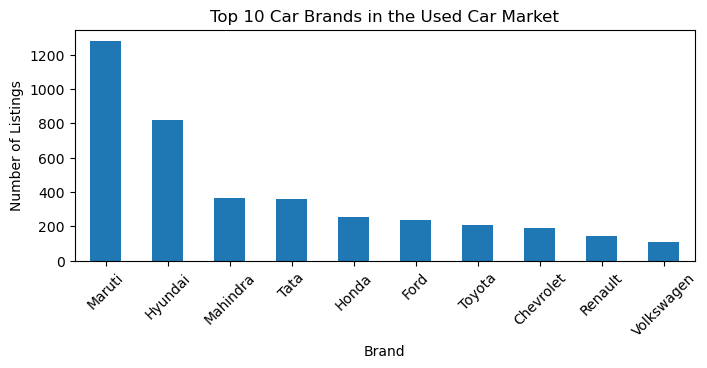

In [17]:
#. Top 10 Car Brands in the Market
import matplotlib.pyplot as plt

top_brands = cardata["Brand"].value_counts().head(10)

plt.figure(figsize=(8, 3))

top_brands.plot(kind='bar')

plt.title("Top 10 Car Brands in the Used Car Market")
plt.xlabel("Brand")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45)

plt.show()

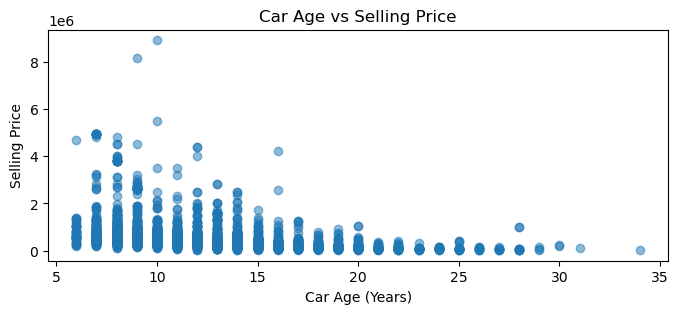

In [45]:
#. Car Age vs Selling Price
plt.figure(figsize=(8, 3))

plt.scatter(cardata["car_age"],
            cardata["selling_price"],
            alpha=0.5)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")

plt.show()



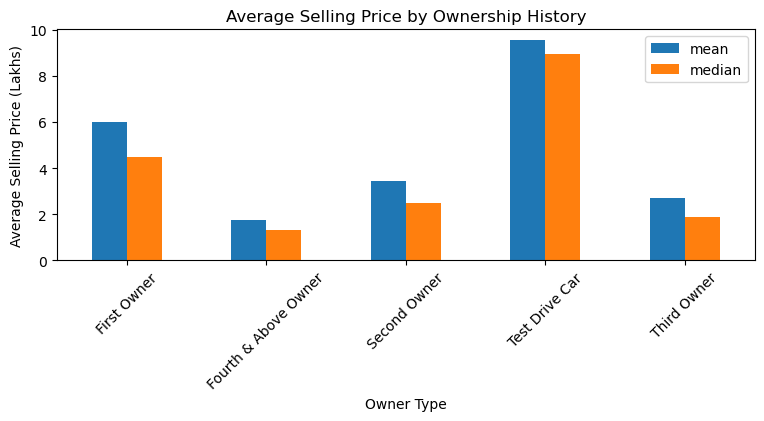

In [46]:
#Average Selling Price by Owner Type

ownership = (
    cardata.groupby("owner")["selling_price"]
    .agg(["mean", "median"])
    .div(100000)
    .round(2)
)
ownership.plot(kind='bar', figsize=(9, 3))

plt.title("Average Selling Price by Ownership History")
plt.xlabel("Owner Type")
plt.ylabel("Average Selling Price (Lakhs)")
plt.xticks(rotation=45)

plt.show()
